In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

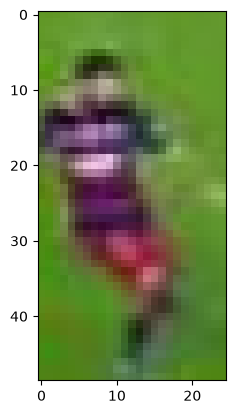

In [3]:
image = cv2.imread('../output_videos/objects_detect/cropped_img.png')
image = cv2.cvtColor(image, cv2. COLOR_BGR2RGB)
plt.imshow(image)

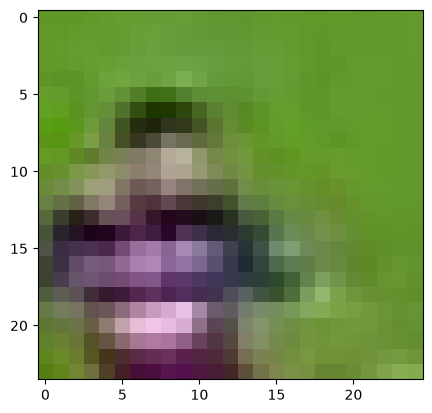

In [4]:
# consider only jersey part
jersey = image[0: int(image.shape[0]/2), :]
plt.imshow(jersey)

In [21]:
image_2d = jersey.reshape(-1, 3)
# perform KMean clustering

kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

#get the cluster labels
labels = kmeans.labels_

# 2D -> 3D
clustered_img = labels.reshape(jersey.shape[0], jersey.shape[1])

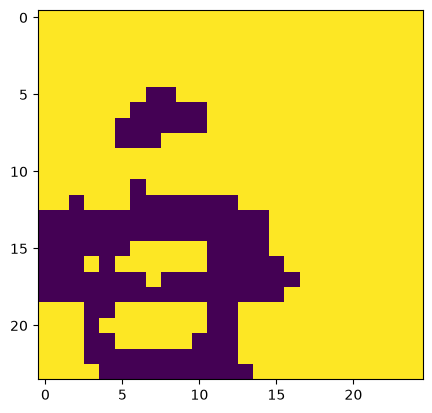

In [22]:
plt.imshow(clustered_img)

In [27]:
# detect which cluster represent background and which represents  player object
corner_clusters = [clustered_img[0, 0], clustered_img[0, -1], clustered_img[-1, 0], clustered_img[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(f"BG: {non_player_cluster}")
player_cluster = 1-non_player_cluster
print(f"player: {player_cluster}")

BG: 1
player: 0


In [28]:
kmeans.cluster_centers_[player_cluster]

array([71.77536232, 59.44927536, 63.        ])